<a href="https://colab.research.google.com/github/jurabekkholiqov/Kholikov_01s/blob/main/05_ml_07_LinerRegression_amaliyot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##5-MODUL. Machine Learning.
Linear Regression


In [1]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/anvarnarz/praktikum_datasets/main/housing_LR.csv', index_col=0)
df.head(10)

,district,rooms,size,level,max_levels,price
0,Юнусабадский,3,57.0,4,4,52000.0
1,Яккасарайский,2,52.0,4,5,56000.0
2,Чиланзарский,2,42.0,4,4,37000.0
3,Чиланзарский,3,65.0,1,4,49500.0
4,Чиланзарский,3,70.0,3,5,55000.0
5,Чиланзарский,1,28.0,1,4,25500.0
6,Чиланзарский,1,30.0,2,4,21200.0
7,Яккасарайский,2,32.0,5,5,20000.0
8,Учтепинский,2,51.0,3,4,26200.0
9,Чиланзарский,1,30.0,1,4,22200.0


##Ustunlar ta'rifi

location - sotilayotgan uy manzili

district - uy joylashgan tuman

rooms - xonalar soni

size - uy maydoni (kv.m)

level - uy

In [2]:
df['district'].value_counts()

,count
district,
Чиланзарский,1616
Мирзо-Улугбекский,1342
Учтепинский,872
Юнусабадский,847
Мирабадский,717
Яккасарайский,628
Яшнободский,456
Шайхантахурский,356
Олмазорский,262


In [28]:
housing = df[df['district']=='Мирзо-Улугбекский']
housing.head()

,district,rooms,size,level,max_levels,price
18,Мирзо-Улугбекский,3,65.0,1,4,32500.0
24,Мирзо-Улугбекский,3,69.0,1,4,49900.0
73,Мирзо-Улугбекский,3,95.0,5,5,50000.0
76,Мирзо-Улугбекский,3,65.0,4,5,41500.0
114,Мирзо-Улугбекский,2,72.0,18,19,55000.0


In [29]:
x = housing['size'].to_numpy()
x

array([65., 69., 95., ..., 50., 85., 18.])

In [30]:
y = housing['price'].to_numpy()
y

array([32500., 49900., 50000., ..., 28000., 90000., 11000.])

Narx va uy maydoni o'rtasida chiziqli bog'liqlik bor ekanini tekshirib ko'ramiz.


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

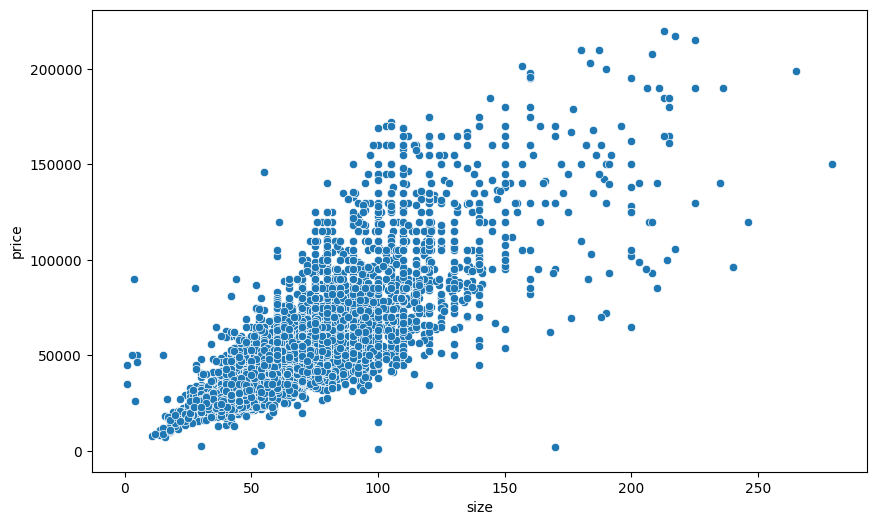

In [32]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='size', y='price')
plt.show()

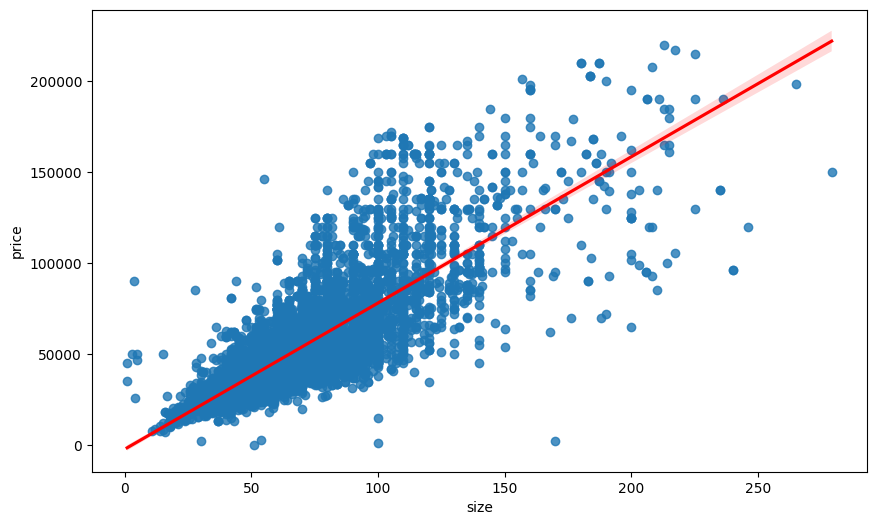

In [33]:
plt.figure(figsize=(10,6))
sns.regplot(data=df, x='size', y='price', line_kws={"color": "red"})
plt.show()

## 1-Vazifa
Sizning vazifangiz yuqoridagi `X` va `y` o'zgaruvchilardan quyidagi formuladan foydalangan xolda $\theta_0$ va $\theta_1$ koeffisientlarni hisoblash.

![Imgur](https://i.imgur.com/zZoXZxI.png)

Bu yerda $\tilde{x}$ - `X` ustun uchun o'rtracha qiymat,  $\tilde{y}$ - `y` ustun uchun o'rtracha qiymat


In [34]:
import numpy as np

In [35]:
xmean = np.mean(x)
ymean = np.mean(y)

In [36]:
theta1 = sum((x-xmean)*(y-ymean))/sum((x-xmean)**2)
theta1

np.float64(824.4125771631817)

In [37]:
theta0 = ymean - theta1*xmean
theta0

np.float64(-3476.7848437808498)

2-Vazifa
X dan bir nechta tasodifiy qiymatlarni ajratib oling va ularga mos keluvchi y ni yuqoridagi koeffisientlar yordamida hisoblab ko'ring.

In [38]:
x_test = housing.sample(10, random_state=42)['size'].to_numpy()
print(f"{x_test=}")
y_test = housing.sample(10, random_state=42)['price'].to_numpy()
print(f"{y_test=}")

x_test=array([ 70.,  50., 200.,  19.,  90.,  60.,  65.,  60., 110.,  80.])
y_test=array([ 66000.,  35000., 195000.,  20500.,  51000.,  63000.,  63000.,
        36000.,  78800.,  75000.])


In [39]:
y_predict = theta0 + theta1*x_test
y_predict

array([ 54232.09555764,  37743.84401438, 161405.73058886,  12187.05412232,
        70720.34710091,  45987.96978601,  50110.03267183,  45987.96978601,
        87208.59864417,  62476.22132927])

## 3-Vazifa

Hisoblangan va asl qiymtlar o'rtasidagi RMSE (root mean square error), MAE (mean absolute error) hisoblang.

##MAE

In [40]:
MAE = np.sum(np.absolute(y_predict-y_test)/len(y_test))
print(f"{MAE=}")

MAE=np.float64(13696.165548953626)


##RMSE

In [41]:
RMSE = np.sqrt(np.sum((y_predict-y_test)**2)/len(y_test))
print(f"{RMSE=}")

RMSE=np.float64(15860.182485315609)
